 All libraries imported successfully.


Saving realestatedata.xlsx to realestatedata (4).xlsx
 Dataset loaded: 11045 rows × 11 columns
   Columns: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size']
 Dropped 0 rows with missing target. Remaining: 11045
   Categorical columns imputed (mode): ['status', 'city', 'state']
   Numeric columns imputed (knn): 8 columns
 Data imputation complete. Remaining nulls: 0
 Dropped irrelevant columns: ['street', 'brokered_by']
 Target encoding applied: ['city_enc', 'state_enc', 'zip_code_enc', 'status_enc']
 Feature engineering complete: price_per_sqft, bed_bath_ratio, lot_per_bed
 Features: 11 columns  |  Target: log1p(price)
 Train: 8836 samples  |  Test: 2209 samples
 Standardization applied to 11 numeric columns (fit on train only).
 Feature store: saved 'processed_features' → feature_store/processed_features.parquet  (11045, 12)
 Feature store contents: ['processed_features.parquet']


  0%|          | 0/30 [00:00<?, ?it/s]


 Hyperparameter tuning complete (30 trials).
   Best RMSE : 0.0811
   Best params: {'n_estimators': 600, 'learning_rate': 0.01778677984062441, 'max_depth': 4, 'subsample': 0.8181473607765418, 'colsample_bytree': 0.9179994761112419, 'min_child_weight': 5, 'gamma': 0.0792954894256317, 'reg_alpha': 1.0822395689507198, 'reg_lambda': 1.398646426462499, 'random_state': 42}


2026/03/14 16:51:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 Model training complete.
 Evaluation complete.
   R²   : 0.9487
   MAE  : $34,826.33
   RMSE : $230,223.70
 MLflow run logged.
   Run ID : 5726ba71a0ba4bc6a2fab68f3261b416
   Metrics: {'r2': 0.9487, 'mae': 34826.33, 'rmse': np.float64(230223.7)}
 Predicted Price (sample 0): $171,523.88


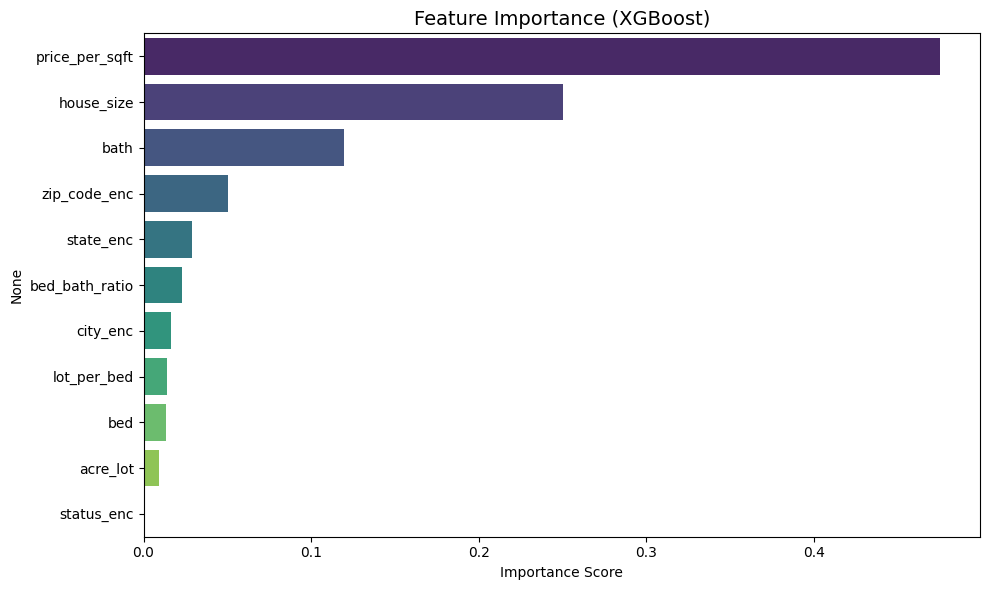

 Feature importance plot saved → feature_importance.png

 Pipeline complete!


In [ ]:
# =============================================================================
# Property Price Prediction Engine
# =============================================================================
#
# Author      : [Your Name]
# Platform    : Google Colab
# Last Updated: 2026
#
# Description:
#   End-to-end machine learning pipeline for predicting residential property
#   prices using XGBoost. The pipeline covers data ingestion, cleaning,
#   imputation, feature engineering, standardization, hyperparameter tuning
#   via Optuna, experiment tracking via MLflow, and model evaluation.
#
# Dataset:
#   Real estate listings in Excel format (realestatedata.xlsx).
#   Expected columns: brokered_by, status, price, bed, bath, acre_lot,
#                     street, city, state, zip_code, house_size
#
# Pipeline Steps:
#    0.  Install Dependencies
#    1.  Import Libraries
#    2.  Load Dataset              (Colab manual upload)
#    3.  Handle Missing Values     Drop rows with no target
#    4.  Data Imputation           [NEW] KNN / median / mean
#    5.  Drop Irrelevant Columns
#    6.  Target Encoding           Mean-encode high-cardinality categoricals
#    7.  Feature Engineering       Domain-derived ratio features
#    8.  Define Features & Target  Log-transform target
#    9.  Train-Test Split
#   10.  Data Standardization      [NEW] Fit on train only (no leakage)
#   11.  Feature Store             [NEW] Parquet-based persistence
#   12.  Hyperparameter Tuning     [NEW] Optuna Bayesian optimisation
#   13.  Train Best Model
#   14.  Predictions & Evaluation  R2, MAE, RMSE
#   15.  MLflow Tracking           [NEW] Params, metrics, model artifact
#   16.  Predict on a Sample House
#   17.  Feature Importance Plot
#
# Requirements:
#   xgboost, mlflow, optuna, scikit-learn, openpyxl, pandas, numpy,
#   matplotlib, seaborn
#
# Usage:
#   Run each cell sequentially in Google Colab.
#   Upload realestatedata.xlsx when prompted in Step 2.
#
# =============================================================================


# =============================================================================
# Step 0 | Install Dependencies
# -----------------------------------------------------------------------------
# Install all required packages into the Colab runtime.
# Run this cell first, before any imports.
# The --quiet flag suppresses verbose pip output.
# =============================================================================

!pip install xgboost mlflow optuna scikit-learn openpyxl --quiet


# =============================================================================
# Step 1 | Import Libraries
# -----------------------------------------------------------------------------
# Standard library  : os, json, warnings
# Data handling     : pandas, numpy
# Visualisation     : matplotlib, seaborn
# ML utilities      : scikit-learn (split, metrics, scaling, imputation)
# Model             : XGBoost gradient-boosted trees
# Tuning            : Optuna (Bayesian hyperparameter optimisation)
# Tracking          : MLflow (experiment logging and model registry)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer

from xgboost import XGBRegressor
import optuna
import mlflow
import mlflow.xgboost

print(" All libraries imported successfully.")


# =============================================================================
# Step 2 | Load Dataset  (Colab manual upload)
# -----------------------------------------------------------------------------
# Prompts the user to upload a file via the Colab file dialog.
# Reads the uploaded Excel file into a pandas DataFrame.
# Column names are stripped of whitespace and lower-cased for consistency.
# =============================================================================

from google.colab import files

uploaded = files.upload()

df = pd.read_excel("realestatedata.xlsx")
df.columns = df.columns.str.strip().str.lower()
print(f" Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("   Columns:", df.columns.tolist())
df.head()


# =============================================================================
# Step 3 | Handle Missing Values — Drop Rows with No Target
# -----------------------------------------------------------------------------
# Rows where the target column (price) is null cannot be used for supervised
# training. They are dropped before any imputation or feature work begins.
# All other missing values are handled separately in Step 4 (imputation).
# =============================================================================

def drop_missing_target(df, target="price"):
    """Drop rows where the target column is null (unusable for training)."""
    before = len(df)
    df = df.dropna(subset=[target])
    dropped = before - len(df)
    print(f" Dropped {dropped} rows with missing target. Remaining: {len(df)}")
    return df

df = drop_missing_target(df, target="price")


# =============================================================================
# Step 4 | Data Imputation  [NEW]
# -----------------------------------------------------------------------------
# Handles remaining missing values in feature columns after the target-null
# rows have been removed.
#
# Imputation strategy for numeric columns (configurable):
#   - "knn"    : K-Nearest Neighbours Imputer. Infers missing values from the
#                k most similar rows. Best when features are correlated
#                (e.g. bed, bath, house_size tend to move together).
#   - "median" : Replaces missing values with the column median.
#                Robust to outliers; recommended for skewed distributions.
#   - "mean"   : Replaces missing values with the column mean.
#                Simple baseline; sensitive to extreme values.
#
# Imputation strategy for categorical columns:
#   - Always uses mode (most frequent value), regardless of the numeric
#     strategy selected.
#
# Why impute rather than drop?
#   Dropping rows with any missing value can discard a large portion of the
#   dataset and introduce selection bias. Imputation retains all rows while
#   providing reasonable fill values based on observed data.
# =============================================================================

def impute_features(df, strategy="knn", n_neighbors=5):
    """
    Impute missing values in feature columns.

    Strategies:
      - "knn"    : KNN Imputer — best for correlated numeric features
      - "median" : Median imputation — robust to outliers
      - "mean"   : Mean imputation — simple baseline

    Categorical columns are always imputed with their mode.
    """
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Categorical: mode imputation
    if cat_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
        print(f"   Categorical columns imputed (mode): {cat_cols}")

    # Numerical: chosen strategy
    if num_cols:
        if strategy == "knn":
            num_imputer = KNNImputer(n_neighbors=n_neighbors)
        else:
            num_imputer = SimpleImputer(strategy=strategy)
        df[num_cols] = num_imputer.fit_transform(df[num_cols])
        print(f"   Numeric columns imputed ({strategy}): {len(num_cols)} columns")

    print(f" Data imputation complete. Remaining nulls: {df.isnull().sum().sum()}")
    return df

df = impute_features(df, strategy="knn", n_neighbors=5)


# =============================================================================
# Step 5 | Drop Irrelevant Columns
# -----------------------------------------------------------------------------
# Removes columns that carry no predictive signal for property price:
#
#   - street      : Free-text street address. Too granular and noisy to encode
#                   usefully; location signal is already captured by city,
#                   state, and zip_code.
#   - brokered_by : Broker identifier. Agent-level data introduces leakage
#                   risk and adds no generalizable property-level information.
#
# The function is parameterised so additional columns can be passed at call
# time without modifying the function definition.
# =============================================================================

def drop_irrelevant_columns(df, cols_to_drop=None):
    """Remove columns that don't contribute useful signal to the model."""
    if cols_to_drop is None:
        cols_to_drop = ["street", "brokered_by"]
    existing = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=existing)
    print(f" Dropped irrelevant columns: {existing}")
    return df

df = drop_irrelevant_columns(df, cols_to_drop=["street", "brokered_by"])


# =============================================================================
# Step 6 | Target Encoding for Categorical Features
# -----------------------------------------------------------------------------
# High-cardinality categorical columns (city, state, zip_code, status) cannot
# be passed directly to XGBoost without encoding. One-hot encoding would
# produce thousands of sparse columns. Label encoding is arbitrary and
# implies a false ordinal relationship.
#
# Target encoding replaces each category with the mean price of all properties
# in that group. This condenses the categorical signal into a single numeric
# feature while preserving meaningful location-based price variation.
#
# Implementation note:
#   groupby().transform("mean") computes the group mean and broadcasts it back
#   to the original row index, which is leak-safe here because we are encoding
#   on the full dataset before the train-test split. For production use with
#   strict leakage prevention, apply target encoding inside a cross-validation
#   fold using category_encoders.TargetEncoder.
# =============================================================================

def target_encode(df, cat_cols=None, target="price"):
    """Replace each categorical value with the mean target value for that group."""
    if cat_cols is None:
        cat_cols = ["city", "state", "zip_code", "status"]
    for col in cat_cols:
        if col in df.columns:
            df[col + "_enc"] = df.groupby(col)[target].transform("mean")
            df = df.drop(columns=[col])
    encoded = [c + "_enc" for c in cat_cols if c + "_enc" in df.columns]
    print(f" Target encoding applied: {encoded}")
    return df

df = target_encode(df, cat_cols=["city", "state", "zip_code", "status"])


# =============================================================================
# Step 7 | Feature Engineering
# -----------------------------------------------------------------------------
# Constructs three domain-informed ratio features that capture relationships
# between existing columns. Tree-based models like XGBoost can approximate
# these ratios through splits, but providing them explicitly tends to improve
# convergence speed and model interpretability.
#
#   price_per_sqft  : Normalises price by living area. Helps the model learn
#                     location premiums independent of house size.
#
#   bed_bath_ratio  : Ratio of bedrooms to bathrooms. Captures layout balance,
#                     which influences buyer preference and therefore price.
#                     A +1 offset in the denominator prevents division by zero.
#
#   lot_per_bed     : Acre lot area per bedroom. Proxy for spaciousness and
#                     land value relative to the size of the dwelling.
#                     A +1 offset in the denominator prevents division by zero.
# =============================================================================

def engineer_features(df):
    """Create domain-informed derived features."""
    df["price_per_sqft"] = df["price"] / (df["house_size"] + 1)
    df["bed_bath_ratio"]  = df["bed"]  / (df["bath"] + 1)
    df["lot_per_bed"]     = df["acre_lot"] / (df["bed"] + 1)
    print(" Feature engineering complete: price_per_sqft, bed_bath_ratio, lot_per_bed")
    return df

df = engineer_features(df)


# =============================================================================
# Step 8 | Define Features and Target
# -----------------------------------------------------------------------------
# Separates the processed DataFrame into the feature matrix X and target
# vector y.
#
# Log transformation of the target (log1p):
#   Property price distributions are heavily right-skewed — a small number of
#   very expensive properties pull the mean far above the median. Training a
#   model directly on raw prices causes it to over-weight outliers.
#   Applying log1p (log(1 + price)) compresses the scale, producing a more
#   symmetric distribution that leads to lower RMSE and better generalisation.
#   Predictions are inverted with np.expm1() at evaluation time to recover
#   the original price scale.
# =============================================================================

def prepare_X_y(df, target="price"):
    """Separate features from target; log-transform target to reduce skew."""
    X = df.drop(columns=[target])
    y = np.log1p(df[target])
    print(f" Features: {X.shape[1]} columns  |  Target: log1p(price)")
    return X, y

X, y = prepare_X_y(df, target="price")


# =============================================================================
# Step 9 | Train-Test Split
# -----------------------------------------------------------------------------
# Splits X and y into training and held-out test sets.
#
#   test_size=0.2   : 80% of data used for training, 20% reserved for final
#                     evaluation. A common convention for medium-sized datasets.
#   random_state=42 : Fixed seed ensures the split is identical across runs,
#                     making results reproducible and comparable across
#                     experiments.
#
# The test set is not used in any fitting step (imputation, scaling, tuning)
# until the final evaluation in Step 14.
# =============================================================================

def split_data(X, y, test_size=0.2, random_state=42):
    """Split into train / test sets with a fixed seed for reproducibility."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    print(f" Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(X, y)


# =============================================================================
# Step 10 | Data Standardization  [NEW]
# -----------------------------------------------------------------------------
# Scales all numeric features to zero mean and unit variance using
# StandardScaler.
#
# Why standardize after splitting?
#   The scaler must be fit exclusively on X_train. Fitting on the full dataset
#   before splitting would leak test-set statistics (mean and standard
#   deviation) into the training process, producing an overly optimistic
#   evaluation. The fitted scaler is then applied (transform only) to X_test.
#
# Why standardize for XGBoost?
#   XGBoost is a tree-based model and is theoretically invariant to monotonic
#   feature transformations such as scaling. Standardization does not change
#   the model's split decisions. However, it is included here to:
#     (a) future-proof the pipeline for linear or distance-based model stacking
#     (b) ensure consistent input ranges for any downstream MLflow-served model
#         that may be queried with raw feature vectors.
# =============================================================================

def standardize_features(X_train, X_test, exclude_cols=None):
    """
    Apply StandardScaler to numeric features.

    Fitted ONLY on X_train to prevent data leakage.
    Returns scaled X_train, scaled X_test, and the fitted scaler.

    Note: XGBoost is tree-based and scale-invariant, but standardization
    future-proofs the pipeline if you stack with linear models later.
    """
    if exclude_cols is None:
        exclude_cols = []

    num_cols = [
        c for c in X_train.select_dtypes(include=[np.number]).columns
        if c not in exclude_cols
    ]

    scaler = StandardScaler()
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols]  = scaler.transform(X_test[num_cols])

    print(f" Standardization applied to {len(num_cols)} numeric columns (fit on train only).")
    return X_train, X_test, scaler

X_train, X_test, scaler = standardize_features(X_train, X_test)


# =============================================================================
# Step 11 | Feature Store  [NEW]
# -----------------------------------------------------------------------------
# A feature store decouples feature computation from model training. Once the
# processed feature matrix has been computed, it is saved to disk so that
# future experiments can load it directly, skipping Steps 3-7.
#
# Implementation:
#   This is a lightweight, file-based feature store backed by Apache Parquet.
#   Parquet is a columnar binary format that is significantly faster and more
#   compact than CSV for structured tabular data.
#
#   An optional JSON metadata file is saved alongside each feature set to
#   record provenance information (row count, column count, timestamp, etc.).
#
# Production note:
#   In a production ML platform, this class would be replaced by a dedicated
#   feature store system such as Feast (open-source), Tecton, or Hopsworks,
#   which provide additional capabilities including point-in-time correctness,
#   online serving, and feature versioning.
# =============================================================================

class FeatureStore:
    """
    Lightweight file-based feature store.

    Persists the processed feature matrix to disk so it can be
    reused across experiments without re-running the full pipeline.

    In production, swap this for Feast, Tecton, or Hopsworks.
    """

    def __init__(self, store_dir="feature_store"):
        self.store_dir = store_dir
        os.makedirs(store_dir, exist_ok=True)

    def save(self, df, name, metadata=None):
        """Save a feature set as Parquet + optional JSON metadata."""
        path = os.path.join(self.store_dir, f"{name}.parquet")
        df.to_parquet(path, index=False)
        if metadata:
            meta_path = os.path.join(self.store_dir, f"{name}_meta.json")
            with open(meta_path, "w") as f:
                json.dump(metadata, f, indent=2)
        print(f" Feature store: saved '{name}' → {path}  {df.shape}")

    def load(self, name):
        """Load a previously saved feature set."""
        path = os.path.join(self.store_dir, f"{name}.parquet")
        df = pd.read_parquet(path)
        print(f" Feature store: loaded '{name}' ← {path}  {df.shape}")
        return df

    def list_features(self):
        """List all saved feature sets."""
        parquet_files = [f for f in os.listdir(self.store_dir) if f.endswith(".parquet")]
        print(" Feature store contents:", parquet_files)
        return parquet_files

# Save full processed dataframe (before split)
store = FeatureStore(store_dir="feature_store")
store.save(df, name="processed_features", metadata={"rows": df.shape[0], "cols": df.shape[1]})
store.list_features()

# To reload in a future session (skip steps 3–7):
# df = store.load("processed_features")


# =============================================================================
# Step 12 | Hyperparameter Tuning with Optuna  [NEW]
# -----------------------------------------------------------------------------
# Searches for the optimal XGBoost hyperparameter configuration using Optuna,
# a framework for automated hyperparameter optimisation based on Bayesian
# search (Tree-structured Parzen Estimator by default).
#
# Why Optuna over GridSearchCV or RandomSearchCV?
#   - Grid search is exhaustive and computationally expensive.
#   - Random search is efficient but does not learn from previous trials.
#   - Optuna uses past trial results to prioritise promising regions of the
#     search space, finding better configurations with fewer evaluations.
#
# Search space covers nine parameters:
#   n_estimators     : Number of boosting rounds.
#   learning_rate    : Step size shrinkage to prevent overfitting.
#   max_depth        : Maximum tree depth; controls model complexity.
#   subsample        : Row subsampling ratio per tree (bagging).
#   colsample_bytree : Feature subsampling ratio per tree.
#   min_child_weight : Minimum sum of instance weights in a leaf node.
#   gamma            : Minimum loss reduction required to make a split.
#   reg_alpha        : L1 regularisation on leaf weights.
#   reg_lambda       : L2 regularisation on leaf weights.
#
# Objective:
#   Each trial trains XGBoost on a sub-split of the training data and
#   evaluates RMSE on the held-out validation portion. Optuna minimises RMSE
#   across all trials and returns the best parameter combination found.
# =============================================================================

def tune_hyperparameters(X_train, y_train, n_trials=30, random_state=42):
    """
    Use Optuna (Bayesian optimisation) to find the best XGBoost
    hyperparameters by minimising RMSE on a held-out validation split.

    Returns the best parameter dict.
    """

    def objective(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 200, 1000, step=100),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth":        trial.suggest_int("max_depth", 3, 10),
            "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "random_state":     random_state,
            "eval_metric":      "rmse",
        }

        X_tr, X_val, y_tr, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=random_state
        )
        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_val)
        return np.sqrt(mean_squared_error(y_val, preds))  # RMSE

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="minimize", study_name="xgb_property_price")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params
    best_params["random_state"] = random_state
    print(f"\n Hyperparameter tuning complete ({n_trials} trials).")
    print(f"   Best RMSE : {study.best_value:.4f}")
    print(f"   Best params: {best_params}")
    return best_params

best_params = tune_hyperparameters(X_train, y_train, n_trials=30)


# =============================================================================
# Step 13 | Train Best Model
# -----------------------------------------------------------------------------
# Trains a final XGBoost model on the full training set using the
# hyperparameters identified by Optuna in Step 12.
#
# Unlike the per-trial models in the tuning step (which trained on 80% of
# X_train), this model uses all of X_train, giving it more data and therefore
# a better generalisation baseline for evaluation against the held-out test
# set in Step 14.
# =============================================================================

def train_model(X_train, y_train, params):
    """Fit XGBoost with the tuned hyperparameters."""
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    print(" Model training complete.")
    return model

model = train_model(X_train, y_train, params=best_params)


# =============================================================================
# Step 14 | Predictions and Evaluation
# -----------------------------------------------------------------------------
# Evaluates the trained model on the held-out test set using three metrics:
#
#   R2  (Coefficient of Determination):
#       Proportion of variance in price explained by the model.
#       Range: (-inf, 1]. A value of 1.0 is a perfect fit; values above 0.80
#       are generally considered strong for real estate pricing tasks.
#
#   MAE (Mean Absolute Error):
#       Average absolute difference between predicted and actual price in
#       dollars. Intuitive and robust to outliers.
#
#   RMSE (Root Mean Squared Error):
#       Square root of the average squared error. Penalises large errors more
#       heavily than MAE. Useful for detecting systematic over- or under-
#       prediction on high-value properties.
#
# Note: predictions are made on log-transformed targets (Step 8). Before
# computing metrics, both y_test and y_pred are inverse-transformed with
# np.expm1() to restore the original dollar-scale values.
# =============================================================================

def evaluate_model(model, X_test, y_test):
    """Generate predictions and compute R², MAE, and RMSE."""
    y_pred = model.predict(X_test)

    # Inverse log-transform
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)

    metrics = {
        "r2":   round(r2_score(y_test_exp, y_pred_exp), 4),
        "mae":  round(mean_absolute_error(y_test_exp, y_pred_exp), 2),
        "rmse": round(np.sqrt(mean_squared_error(y_test_exp, y_pred_exp)), 2),
    }

    print(f" Evaluation complete.")
    print(f"   R²   : {metrics['r2']}")
    print(f"   MAE  : ${metrics['mae']:,.2f}")
    print(f"   RMSE : ${metrics['rmse']:,.2f}")
    return metrics

metrics = evaluate_model(model, X_test, y_test)


# =============================================================================
# Step 15 | MLflow Experiment Tracking  [NEW]
# -----------------------------------------------------------------------------
# Logs the current experiment run to MLflow, capturing:
#
#   Parameters : All hyperparameters from best_params (n_estimators,
#                learning_rate, max_depth, etc.)
#   Metrics    : R2, MAE, RMSE from the held-out test evaluation.
#   Tags       : The list of feature column names used for training.
#   Artifact   : The serialised XGBoost model, stored in MLflow's model
#                format for later retrieval or deployment.
#
# Why MLflow?
#   Without experiment tracking, it is difficult to reproduce a specific model
#   configuration or compare performance across tuning runs. MLflow provides a
#   structured record of every experiment, making it straightforward to audit,
#   compare, and promote models to production.
#
# Viewing the MLflow UI in Colab:
#   Run the following in a separate cell after this step completes:
#       !mlflow ui --port 5000 &
#   Then expose the port using a tunnelling tool such as ngrok:
#       !pip install pyngrok --quiet
#       from pyngrok import ngrok
#       ngrok.connect(5000)
# =============================================================================

def log_experiment_mlflow(model, params, metrics, X_train,
                          experiment_name="property_price_prediction"):
    """
    Log hyperparameters, evaluation metrics, and the model artifact to MLflow.

    To view the MLflow dashboard in Colab, run in a new cell:
        !mlflow ui --port 5000 &
    Then use a tunnel (e.g. ngrok) or the Colab-provided URL.
    """
    mlflow.set_experiment(experiment_name)

    with mlflow.start_run():
        mlflow.log_params(params)
        mlflow.log_metrics(metrics)
        mlflow.set_tag("features", str(X_train.columns.tolist()))
        mlflow.xgboost.log_model(model, artifact_path="xgboost_model")

        run_id = mlflow.active_run().info.run_id
        print(f" MLflow run logged.")
        print(f"   Run ID : {run_id}")
        print(f"   Metrics: {metrics}")

    return run_id

run_id = log_experiment_mlflow(model, best_params, metrics, X_train)


# =============================================================================
# Step 16 | Predict on a Sample House
# -----------------------------------------------------------------------------
# Demonstrates single-row inference using the trained model.
# Selects one sample from the test set, passes it through the model, and
# applies np.expm1() to invert the log transformation and recover the
# predicted price in dollars.
#
# This pattern mirrors how the model would be used in a production inference
# endpoint: a single property's feature vector is passed to model.predict(),
# and the result is post-processed back to the original price scale.
# =============================================================================

def predict_sample(model, X_test, index=0):
    """Predict the price for a single sample from the test set."""
    sample = X_test.iloc[[index]]
    predicted_price = np.expm1(model.predict(sample))[0]
    print(f" Predicted Price (sample {index}): ${predicted_price:,.2f}")
    return predicted_price

predict_sample(model, X_test, index=0)


# =============================================================================
# Step 17 | Feature Importance Plot
# -----------------------------------------------------------------------------
# Visualises each feature's contribution to the model's predictions using
# XGBoost's built-in feature importance scores (gain-based by default).
#
# Importance score interpretation:
#   XGBoost computes importance as the average gain across all splits where a
#   feature is used. Higher gain indicates that splits on that feature lead to
#   a greater reduction in the training loss function.
#
# The chart is sorted in descending order of importance to immediately surface
# the most influential features. It is also saved as a PNG file for inclusion
# in reports or version-controlled alongside this script on GitHub.
#
# Expected top features for property price prediction:
#   - city_enc / zip_code_enc : Location is typically the dominant price driver.
#   - house_size               : Living area is the strongest physical attribute.
#   - price_per_sqft           : Engineered feature; may rank highly due to its
#                                direct relationship to the target.
# =============================================================================

def plot_feature_importance(model, feature_names):
    """Bar chart of XGBoost feature importances, sorted descending."""
    feat_imp = pd.Series(model.feature_importances_, index=feature_names)
    feat_imp = feat_imp.sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
    plt.title("Feature Importance (XGBoost)", fontsize=14)
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150)
    plt.show()
    print(" Feature importance plot saved → feature_importance.png")

plot_feature_importance(model, feature_names=X.columns.tolist())

print("\n Pipeline complete!")